In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway, kruskal

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

In [2]:
ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")



Cleaned climate datasets for the five countries were loaded and combined into a single dataframe. This enables direct comparison of temperature trends, precipitation variability, and climate stress indicators across countries.

In [3]:
df = pd.concat([
    ethiopia,
    kenya,
    sudan,
    tanzania,
    nigeria
], ignore_index=True)

In [4]:
df["DATE"] = pd.to_datetime(df["DATE"])
df["YEAR"] = df["DATE"].dt.year
df["MONTH"] = df["DATE"].dt.month

In [5]:
monthly_temp = df.groupby(["Country","YEAR","MONTH"])["T2M"].mean().reset_index()

monthly_temp["DATE"] = pd.to_datetime(
    monthly_temp["YEAR"].astype(str) + "-" +
    monthly_temp["MONTH"].astype(str) + "-01"
)

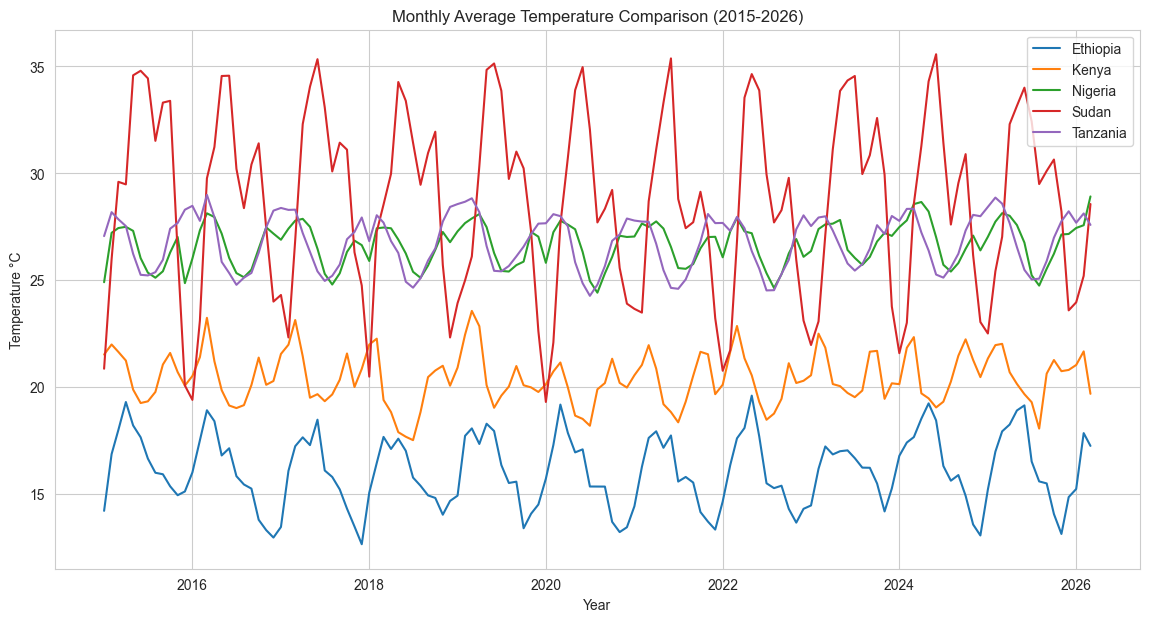

In [6]:
plt.figure(figsize=(14,7))

for country in monthly_temp["Country"].unique():
    temp = monthly_temp[monthly_temp["Country"] == country]
    plt.plot(temp["DATE"], temp["T2M"], label=country)

plt.title("Monthly Average Temperature Comparison (2015-2026)")
plt.xlabel("Year")
plt.ylabel("Temperature °C")
plt.legend()
plt.show()



The following chart shows monthly average air temperature (T2M) for all five countries from 2015 to 2026. Comparing these trends helps identify hotter countries and countries experiencing stronger warming signals over time.

In [7]:
temp_summary = df.groupby("Country")["T2M"].agg(
    Mean="mean",
    Median="median",
    Std="std"
).round(2)

temp_summary

,Mean,Median,Std
Country,,,
Ethiopia,16.07,16.04,1.90
Kenya,20.43,20.36,1.44
Nigeria,26.66,26.82,1.12
Sudan,28.76,29.16,4.68
Tanzania,26.80,26.99,1.33




Countries with higher mean temperatures are exposed to greater long-term heat stress. A higher standard deviation suggests stronger seasonal swings or more variable temperatures. Median values help confirm whether extreme values are skewing averages.

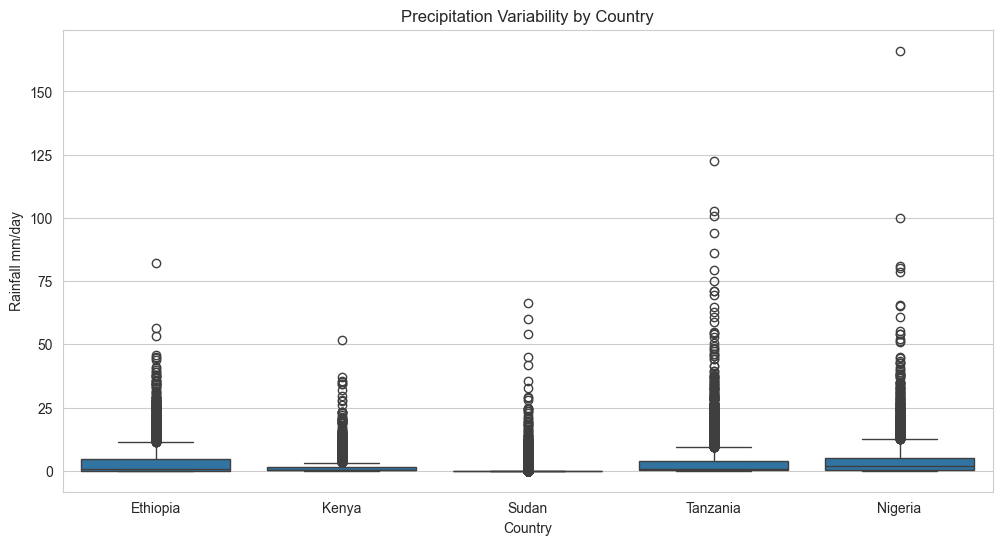

In [8]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df, x="Country", y="PRECTOTCORR")

plt.title("Precipitation Variability by Country")
plt.ylabel("Rainfall mm/day")
plt.show()



The boxplot below compares daily precipitation across countries. Wider spreads and more outliers indicate unstable rainfall patterns, which may increase flood and drought risks.

In [9]:
rain_summary = df.groupby("Country")["PRECTOTCORR"].agg(
    Mean="mean",
    Median="median",
    Std="std"
).round(2)

rain_summary

,Mean,Median,Std
Country,,,
Ethiopia,3.63,0.82,6.29
Kenya,1.47,0.38,3.18
Nigeria,4.21,1.84,7.27
Sudan,0.64,0.00,3.06
Tanzania,3.74,0.64,8.00




Countries with higher precipitation variability may face alternating wet and dry extremes. A larger standard deviation in rainfall often signals stronger climate uncertainty, affecting agriculture and water planning.

In [10]:
heat = df[df["T2M_MAX"] > 35]

heat_counts = heat.groupby("Country").size().sort_values(ascending=False)

heat_counts

Country
Sudan    2694
dtype: int64

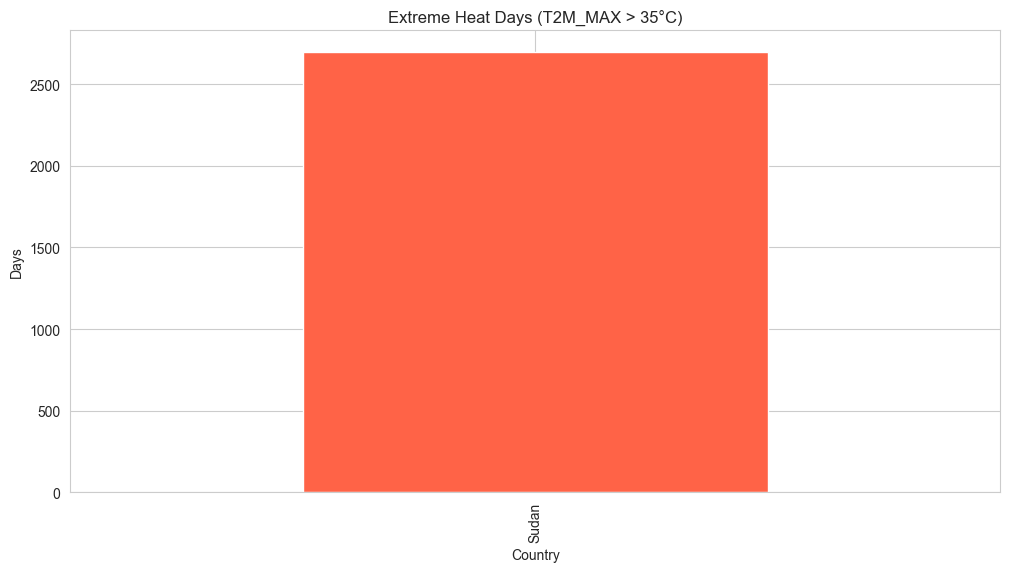

In [11]:
heat_counts.plot(kind="bar", color="tomato")

plt.title("Extreme Heat Days (T2M_MAX > 35°C)")
plt.ylabel("Days")
plt.show()



Extreme heat days are defined as days where maximum temperature (T2M_MAX) exceeded 35°C. Frequent exposure to extreme heat can reduce labor productivity, increase water stress, and threaten public health.

In [12]:
dry = df[df["PRECTOTCORR"] < 1]

dry_counts = dry.groupby("Country").size().sort_values(ascending=False)

dry_counts

Country
Sudan       3696
Kenya       2831
Tanzania    2303
Ethiopia    2161
Nigeria     1595
dtype: int64

## Climate Vulnerability Ranking

Countries were ranked using a combined climate stress score based on:

- Frequency of extreme heat days
- Number of dry days
- Rainfall variability
- Observed temperature trends

Higher combined stress indicators imply greater climate vulnerability.

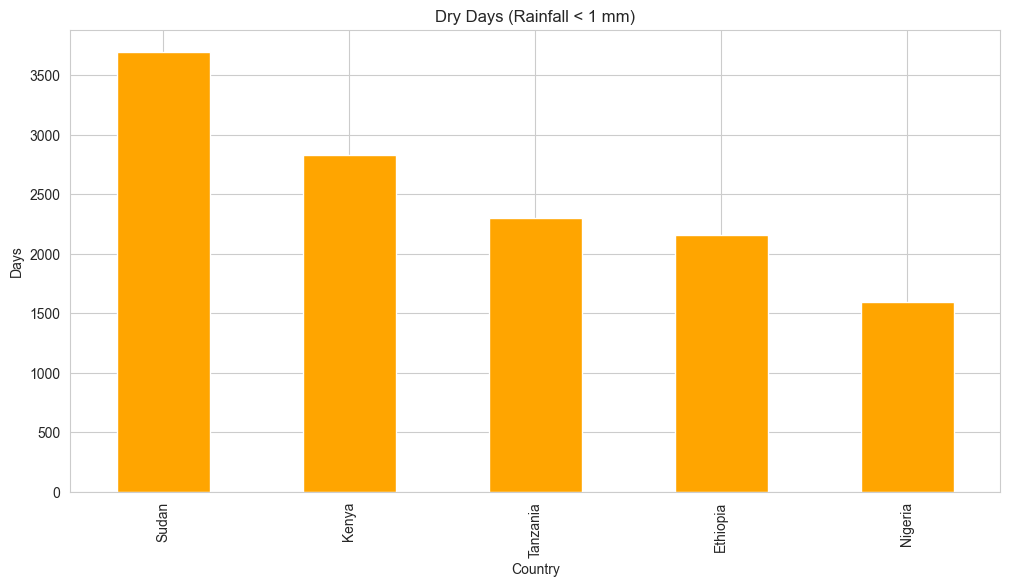

In [13]:
dry_counts.plot(kind="bar", color="orange")

plt.title("Dry Days (Rainfall < 1 mm)")
plt.ylabel("Days")
plt.show()

In [14]:
groups = [
    df[df["Country"]=="Ethiopia"]["T2M"],
    df[df["Country"]=="Kenya"]["T2M"],
    df[df["Country"]=="Sudan"]["T2M"],
    df[df["Country"]=="Tanzania"]["T2M"],
    df[df["Country"]=="Nigeria"]["T2M"]
]

stat, p = f_oneway(*groups)

print("F-statistic:", stat)
print("P-value:", p)

F-statistic: 18938.745697069917
P-value: 0.0




The p-value is below 0.05, indicating statistically significant differences in temperature among the five countries. This suggests that climate conditions are not uniform across the region.

In [15]:
ranking = pd.DataFrame({
    "Heat_Days": heat_counts,
    "Dry_Days": dry_counts,
    "Rain_Variability": df.groupby("Country")["PRECTOTCORR"].std()
})

ranking = ranking.fillna(0)

ranking["Score"] = (
    ranking["Heat_Days"].rank(ascending=False) +
    ranking["Dry_Days"].rank(ascending=False) +
    ranking["Rain_Variability"].rank(ascending=False)
)

ranking = ranking.sort_values("Score")
ranking

,Heat_Days,Dry_Days,Rain_Variability,Score
Country,,,,
Sudan,2694.0,3696,3.057672,7.0
Tanzania,0.0,2303,8.003947,7.5
Kenya,0.0,2831,3.180228,9.5
Ethiopia,0.0,2161,6.289061,10.5
Nigeria,0.0,1595,7.266742,10.5




This cross-country comparison shows that African climate risks are diverse but intensifying. Some countries face severe heat stress, while others experience unstable rainfall and drought pressure. These findings support a stronger, evidence-based African climate finance agenda at COP32, led by Ethiopia as host nation.